In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('c:/users/pvpal/project/DATA/final_walmart.csv')

In [3]:
df.head()

,store,week_date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment
0,1,01-04-2011,1495064.75,0,59.17,3.524,214.837166,7.682
1,1,01-06-2012,1624477.58,0,77.95,3.501,221.747214,7.143
2,1,01-07-2011,1488538.09,0,85.55,3.524,215.184137,7.962
3,1,01-10-2010,1453329.50,0,71.89,2.603,211.671989,7.838
4,1,02-03-2012,1688420.76,0,60.96,3.630,220.848045,7.348


In [21]:
import numpy as np
df = df.sort_values('week_date')
df = df.groupby('week_date')['weekly_sales'].sum().reset_index()
df['time_index'] = np.arange(len(df))



In [22]:
df['week_date'] = pd.to_datetime(df['week_date'], format="%d-%m-%Y")

In [23]:
df['week_of_year'] = df['week_date'].dt.isocalendar().week

In [24]:
df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)

In [25]:
X = df[['time_index', 'week_sin', 'week_cos']]
y = df['weekly_sales']

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
df['prediction'] = model.predict(X)

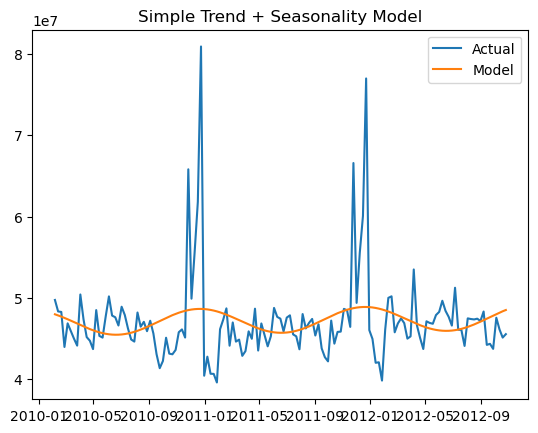

In [28]:
import matplotlib.pyplot as plt

plt.plot(df['week_date'], df['weekly_sales'], label='Actual')
plt.plot(df['week_date'], df['prediction'], label='Model')

plt.legend()
plt.title("Simple Trend + Seasonality Model")
plt.show()

In [29]:
future_steps = 12
import numpy as np

last_index = df['time_index'].iloc[-1]
future_time_index = np.arange(last_index + 1, last_index + 1 + future_steps)

In [30]:
future_dates = pd.date_range(
    start=df['week_date'].iloc[-1],
    periods=future_steps + 1,
    freq='W'
)[1:]

In [31]:
future_df = pd.DataFrame({
    'week_date': future_dates,
    'time_index': future_time_index
})

In [32]:
future_df['week_of_year'] = future_df['week_date'].dt.isocalendar().week

In [33]:
import numpy as np

future_df['week_sin'] = np.sin(2 * np.pi * future_df['week_of_year'] / 52)
future_df['week_cos'] = np.cos(2 * np.pi * future_df['week_of_year'] / 52)

In [34]:
X_future = future_df[['time_index', 'week_sin', 'week_cos']]

future_df['forecast'] = model.predict(X_future)

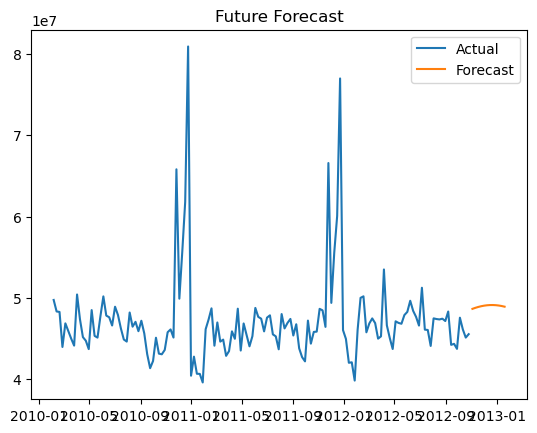

In [35]:
import matplotlib.pyplot as plt

plt.plot(df['week_date'], df['weekly_sales'], label='Actual')
plt.plot(future_df['week_date'], future_df['forecast'], label='Forecast')

plt.legend()
plt.title("Future Forecast")
plt.show()

In [37]:
future_df.to_csv("c:/users/pvpal/project/outputs/forecastLatest.csv", index=False)

In [38]:
import joblib

joblib.dump(model, "c:/users/pvpal/project/models/sales_forecast_model.pkl")

['c:/users/pvpal/project/models/sales_forecast_model.pkl']